In [1]:
import matplotlib.pyplot as plt
import time
import random
from collections import deque
import tensorflow as tf
from tqdm import tqdm 
from tensorflow.keras import Sequential 
from tensorflow.keras.activations import relu, linear
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import RMSprop
import math
from tensorflow.keras.optimizers import Adam
from IPython.display import clear_output
from random import sample
from tqdm import trange
import pandas as pd
import gc
import os
import numpy as np 
import time
import copy


In [2]:
physical_devices = tf.config.list_physical_devices('GPU')
print("Num GPUs:", len(physical_devices))


Num GPUs: 1


In [3]:
state_space=2
obs_space=1
action_space=11
intermediate_dim=16

In [4]:
all_states=[]
for i in range(0,201):
    all_states.append(i-100)
all_states

[-100,
 -99,
 -98,
 -97,
 -96,
 -95,
 -94,
 -93,
 -92,
 -91,
 -90,
 -89,
 -88,
 -87,
 -86,
 -85,
 -84,
 -83,
 -82,
 -81,
 -80,
 -79,
 -78,
 -77,
 -76,
 -75,
 -74,
 -73,
 -72,
 -71,
 -70,
 -69,
 -68,
 -67,
 -66,
 -65,
 -64,
 -63,
 -62,
 -61,
 -60,
 -59,
 -58,
 -57,
 -56,
 -55,
 -54,
 -53,
 -52,
 -51,
 -50,
 -49,
 -48,
 -47,
 -46,
 -45,
 -44,
 -43,
 -42,
 -41,
 -40,
 -39,
 -38,
 -37,
 -36,
 -35,
 -34,
 -33,
 -32,
 -31,
 -30,
 -29,
 -28,
 -27,
 -26,
 -25,
 -24,
 -23,
 -22,
 -21,
 -20,
 -19,
 -18,
 -17,
 -16,
 -15,
 -14,
 -13,
 -12,
 -11,
 -10,
 -9,
 -8,
 -7,
 -6,
 -5,
 -4,
 -3,
 -2,
 -1,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83

In [5]:
class QModel:
    def __init__(self, input_dim, output_dim, lr):
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.lr = lr
        self.Qpolicy = self.create()
        self.Qtarget = self.create() 
        self.Qtarget.set_weights(self.Qpolicy.get_weights())
        
    def create(self):
        model = Sequential()
        model.add(tf.keras.layers.InputLayer(input_shape=(1,state_space)))
        model.add(Dense(512,activation = 'relu'))
        model.add(Dense(256, activation = 'relu'))
        model.add(Dense(128, activation = 'relu'))
        model.add(Dense(self.output_dim, activation = 'linear'))
        model.compile(optimizer =tf.keras.optimizers.legacy.Adam(learning_rate=self.lr), loss = "mse", metrics = ['accuracy'])
        return model

In [6]:
GAMMA = 0.99
LEARNING_RATE = 1e-6

MEMORY_SIZE = 10000
BATCH_SIZE = 32

EPSILON_MAX = 1.0
EPSILON_MIN = 0.1
EXPLORATION_DECAY = 0.997

In [7]:
class DQNSolver:
    def __init__(self,state_space,action_space, decay_coe = 0.99, 
                  memory_size = MEMORY_SIZE,EXPLORATION_DECAY=EXPLORATION_DECAY,LEARNING_RATE=LEARNING_RATE,EPSILON_MAX=EPSILON_MAX,EPSILON_MIN=EPSILON_MIN,BATCH_SIZE=BATCH_SIZE):
        
        #self.env = gym.make('CartPole-v0')

        self.states = state_space
        self.n_actions = action_space
        
        self.actions = [i for i in range(self.n_actions)]
        
        self.lr = LEARNING_RATE
        self.gamma = GAMMA
        self.epsilon = EPSILON_MAX
        self.decay_coe = decay_coe
        self.min_eps = EPSILON_MIN
        #self.episodes = episodes
        self.batch_size = BATCH_SIZE
        self.memory = deque(maxlen = memory_size) # replay memory 
        
        self.terminal_state = False # end of the episode
        self.target_counter = 0 
        
        # Plot data
        #self.timestep = self.episodes / 10

        
        
        
        self.model = QModel((1,self.states), self.n_actions, self.lr)
        # Smooth epsilon 
        # self.a = 0.35
        # self.b = 0.1
        # self.c = 0.01
        
    def state_shape(self,states):
        states = np.array(states)
        return states.reshape(-1,*states.shape)
    def update_target_model(self):
        """
        Updates the current target_q_net with the q_net which brings all the
        training in the q_net to the target_q_net.
        :return: None
        """
        self.model.Qtarget.set_weights(self.model.Qpolicy.get_weights())
    def decrement_epsilon(self):
        '''
        if self.epsilon > self.min_eps:
            self.epsilon *= self.decay_coe
        else:
            self.epsilon = self.min_eps
        '''
        # s_time = (time - self.a*self.episodes) / (self.b*self.episodes) 
        # cosh = np.cosh(math.exp(-s_time))
        # self.epsilon = 1 - (1/cosh + (time*self.c/self.episodes))
        if self.epsilon>self.min_eps:
            self.epsilon*=EXPLORATION_DECAY
        else:
            self.epsilon=self.min_eps
    def forget(self):
        self.memory.clear()

    def remember(self, s, a, r, s_, done):
        self.memory.append([self.state_shape(s), a, r, self.state_shape(s_), done])
        
    def act(self, states):
        if np.random.random() > (1 - self.epsilon):
            action = np.random.choice(self.actions,1,p=[1/11,1/11,1/11,1/11,1/11,1/11,1/11,1/11,1/11,1/11,1/11])[0]
        else:
            states = self.state_shape(states)
            states.reshape(1,1,self.states)
#             states=[states]
#             states=np.array(states)
            #print(states.shape)
            action = np.argmax(np.array(self.model.Qpolicy.predict_on_batch(states)))
            
        return action
            
    def minibatch(self):
        if np.random.random() > 0.1:
            return random.sample(self.memory, self.batch_size)
        else:
            x=list(self.memory)
            x.sort(key=lambda x: x[2],reverse=True)
            return x[:self.batch_size]
    

        #plt.savefig(r'RL/loss - e{}v2.png'.format(episode), dpi = 500)
        
    def train(self):
        # X - states passed to the NN, y - target
        
        X, y = [], []
        
        if len(self.memory) >= self.batch_size: 
            SARS = self.minibatch()
            s =np.array( [row[0] for row in SARS])
            s=s.reshape(BATCH_SIZE,1,state_space)
            #print(s.shape)
            qvalue = np.array(self.model.Qpolicy.predict_on_batch(s))
            #print(qvalue)
            s_ =np.array( [row[3] for row in SARS])
            s_=s_.reshape(BATCH_SIZE,1,state_space)
            future_qvalue = np.array(self.model.Qtarget.predict_on_batch(s_))
            #print("2")
            #print(future_qvalue)

            for index, (state, action, reward, state_, done) in enumerate(SARS):
                if done == True:
                    Qtarget = reward
                else:
                    Qtarget = reward + self.gamma * np.max(future_qvalue[index][0])
            
                qcurr = qvalue[index][0]
                #print(qcurr)
                qcurr[int(action)] = Qtarget 
                #print(qcurr)
                X.append(state)
                y.append(qcurr)
#             X_dataset=tf.data.Dataset.from_tensor_slices(X).batch(64)
#             y_dataset=tf.data.Dataset.from_tensor_slices(y).batch(64)
#             final_dataset=tf.data.Dataset.zip((X_dataset, y_dataset))
            X, y = np.array(X).reshape(self.batch_size,1,self.states), np.array(y).reshape(self.batch_size, 1, self.n_actions)
                                 
            loss = self.model.Qpolicy.train_on_batch(X, y,return_dict=True)
            
            

In [8]:
class Encoder(tf.keras.layers.Layer):
  def __init__(self,state_space, intermediate_dim):
    super(Encoder, self).__init__()
    self.input_layer=tf.keras.layers.InputLayer(input_shape=(1,4))
    self.hidden_layer1=tf.keras.layers.Dense(
      units=intermediate_dim,
      activation=tf.keras.activations.relu,
      kernel_initializer='he_uniform'
    )
    #self.batchnorm_layer1=tf.keras.layers.BatchNormalization()
    self.hidden_layer2 = tf.keras.layers.Dense(
      units=intermediate_dim,
      activation=tf.keras.activations.relu,
      kernel_initializer='he_uniform',activity_regularizer=tf.keras.regularizers.L1(0.0001)
    )
    #self.batchnorm_layer2=tf.keras.layers.BatchNormalization()
    self.output_layer = tf.keras.layers.Dense(
      units=state_space,
      activation=tf.keras.activations.linear,activity_regularizer=tf.keras.regularizers.L1(0.0001)
    )
    
  def call(self, input_features):
    activation0=self.input_layer(input_features)
    activation1 = self.hidden_layer1(activation0)
    #activation1=self.batchnorm_layer1(activation0)
    activation2=self.hidden_layer2(activation1)
    #activation2=self.batchnorm_layer2(activation1)
    return self.output_layer(activation2)

In [9]:
class Decoder(tf.keras.layers.Layer):
  def __init__(self, intermediate_dim, obs_space):
    super().__init__()
    self.hidden_layer1 = tf.keras.layers.Dense(
      units=intermediate_dim,
      activation=tf.keras.activations.relu,
      kernel_initializer='he_uniform'
    )
    #self.batchnorm_layer1=tf.keras.layers.BatchNormalization()
    self.hidden_layer2 = tf.keras.layers.Dense(
      units=intermediate_dim,
      activation=tf.keras.activations.relu,
      kernel_initializer='he_uniform'
    )
    #self.batchnorm_layer2=tf.keras.layers.BatchNormalization()
    self.output_layer = tf.keras.layers.Dense(
      units=obs_space,
      activation=tf.keras.activations.linear
    )
  
  def call(self, inputs):
    input_features=inputs[0]
    var=inputs[1]
    if(len(input_features.get_shape())==2):
      activation1 = self.hidden_layer1(tf.concat((input_features,var),axis=1))
    else:
      # print("1")
      temp=tf.map_fn(lambda x: tf.concat((x[0],x[1]),axis=1),inputs,fn_output_signature=tf.float32)
      # print(temp)
      # temp=[]
      # for i in range(len(input_features)):
      #     temp.append(tf.concat((input_features[i],var[i]),axis=1))
      # temp=tf.convert_to_tensor(temp,dtype=tf.float32)
      activation1 = self.hidden_layer1(temp)
      del temp
    #activation2=self.batchnorm_layer1(activation1)
    activation2=self.hidden_layer2(activation1)
    #activation4=self.batchnorm_layer2(activation3)

    return self.output_layer(activation2)

In [10]:
class Autoencoder(tf.keras.Model):
  def __init__(self, intermediate_dim, state_space,obs_space):
    super(Autoencoder, self).__init__()
    self.encoder = Encoder(intermediate_dim=intermediate_dim,state_space=state_space)
    
    self.decoder = Decoder(
      intermediate_dim=intermediate_dim,
      obs_space=obs_space
    )
    
  
  def call(self, inputs):
    input_features=inputs[0]
    var=inputs[1]
    code = self.encoder(input_features)
    #self.var=tf.Variable(var,trainable=False)
    reconstructed = self.decoder([code,var])
    return reconstructed


# opt = tf.keras.optimizers.legacy.Adam(learning_rate=LEARNING_RATE)

In [11]:
# def loss(model,input_features, obs,var):
#   reconstruction_error = tf.reduce_mean(tf.square(tf.subtract(model(input_features,var), obs)))
#   return reconstruction_error

loss_fn=tf.keras.losses.MeanSquaredError()

@tf.function  
def train( model,input_features,obs,var,opt,loss_fn=loss_fn):
  with tf.GradientTape() as tape:
    output=model([input_features,var])
    loss=tf.reduce_mean(loss_fn(obs,output))
    gradients = tape.gradient(loss, model.trainable_variables)
  gradient_variables = zip(gradients, model.trainable_variables)
  opt.apply_gradients(gradient_variables)
  return loss

In [12]:
class Non_Markovian_Environment:

    def __init__(self,memory_len,action_space,all_states,probability_matrix) -> None:
        self.all_states=all_states
        # self.memory=deque(maxlen=memory_len)
        self.memory=0
        self.action_space=action_space
        self.probability_matrix=probability_matrix
    def reset(self):
        self.memory=0
        # self.memory.append(np.array([[0]]))
        # self.memory.append(np.array([[0]]))
        return random.choice(self.all_states)
    # def clear_memory(self):
    #     self.memory.clear()

    def remember(self,state):
        # self.memory.append(state)
        self.memory+=state[0][0]
    def step(self,state,action):
        x=copy.deepcopy(state)
        done=False
        actions=[-5,-4,-3,-2,-1,0,1,2,3,4,5]
        new_state_temp=0
        # print(sum(self.memory))
        # print(self.memory)
        new_state_temp=x+(self.memory)%10-5+actions[action]
        # print((sum(self.memory)[0][0]+action)%5)
        # print(x)
        # print("-----")
        # print(new_state_temp)
        # noise=np.random.choice([-2,-1,0,1,2],replace=True,p=self.probability_matrix)
        # print(self.all_actions)
        # print(noise)
        new_state=new_state_temp
        if(new_state>100):
            new_state=100
        if(new_state<-100):
            new_state=-100
        if(new_state==0):
            reward=100
            done=True
        else:
            reward=-abs(new_state)/100
            # if new_state>50:
            #     reward=state-new_state
            # else:
            #     reward=new_state-state
            done=False
        return [new_state,reward,done]
    
        
        

In [13]:
dqn_solver=DQNSolver(state_space=state_space,action_space=action_space)
env=Non_Markovian_Environment(memory_len=3,action_space=action_space,all_states=all_states,probability_matrix=[0.05,0.2,0.5,0.2,.05])
autoencoder = Autoencoder(
  intermediate_dim=intermediate_dim,
  state_space=state_space,obs_space=obs_space
)

2023-12-02 13:35:01.423734: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2023-12-02 13:35:01.423756: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2023-12-02 13:35:01.423760: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2023-12-02 13:35:01.423789: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2023-12-02 13:35:01.423802: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [14]:
env.reset()

-66

In [15]:
env.remember(np.array([[18]]))

In [16]:
env.memory

18

In [17]:
env.step(5,1)


[4, -0.04, False]

In [18]:
def data_collection(total_episodes,dqn_solver,autoencoder,eps_decr=False):

    S_series=[]
    S_actual_series=[]
    O_series=[]
    U_series=[]
    R_series=[]
    O_predicted_series=[]
    Done_series=[]
    O_series.append(np.array([[0]]))
    O_predicted_series.append(np.array([[0]]))
    encoder=autoencoder.encoder
    decoder=autoencoder.decoder
    ep_no=0
    prev_obs=0
    i=0
    while(ep_no<total_episodes):
        s0=env.reset()
        #s0=np.reshape(s0,[1,state_space])
        print(s0)
        step=0
        done=False
        j=0
        while (not done) and (j<150):
            j+=1
            if(step==0):
                
                prev_obs=s0
                s=np.array([[s0,0]])
                s=np.reshape(s,(1,state_space))
                env.remember(s)
                S_actual_series.append(s)
            else:
                s=encoder(tf.concat((S_series[i-1],O_series[i],U_series[i-1]),axis=1))
                s=np.reshape(s,(1,state_space))
                # s=s.tolist()
                # s[0][0]=np.tanh(s[0][0])*4.8
                # s[0][2]=np.tanh(s[0][2])*0.418
                # s=np.array(s)

            
            s=np.reshape(s,(1,state_space))
            s=s.astype('float32')
            
            S_series.append(s)
            if((i>0)and (not(step==0))):
                # print(S_series[i-1][0],U_series[i-1][0][0],R_series[i-1],S_series[i][0],Done_series[i-1],O_series[i])
                dqn_solver.remember(S_series[i-1][0],U_series[i-1][0][0],R_series[i-1],S_series[i][0],Done_series[i-1])
                dqn_solver.train()
            action=dqn_solver.act(s)
            obs, reward, done = env.step(prev_obs,int(action))
            
            prev_obs=obs
            
            # print("....")
            # print(obs)
            # print("....")
            Done_series.append(done)
            #actual_state=np.reshape(actual_state,[1,state_space])
            #S_actual_series.append(actual_state)
            action=np.array([[action]])
            action=action.astype('float32')
            U_series.append(action)
            obs=np.reshape(obs,[1,obs_space])
            env.remember(obs)
            
            O_series.append(obs)
            
            R_series.append(reward)
            # print(s.shape)
            # print(action.shape)
            obs_pred=decoder([s,action])
            obs_pred=np.reshape(obs_pred,[1,obs_space])
            obs_pred=obs_pred.tolist()
            # obs_pred[0][0]=np.tanh(obs_pred[0][0])*4.8
            # obs_pred[0][1]=np.tanh(obs_pred[0][1])*0.418
            obs_pred=np.array(obs_pred)
            O_predicted_series.append(obs_pred)
            
            
                
            i+=1
            step+=1
            if(done==True):
                terminal_state_pred=encoder(tf.concat((s,np.reshape([0],[1,obs_space]),action),axis=1))
                terminal_state_pred=np.reshape(terminal_state_pred,(1,state_space))
                # print(terminal_state_pred)
                # print(S_series[i-1][0])
                # print(R_series[i-1])
                
                dqn_solver.remember(s[0],action[0][0],reward,terminal_state_pred[0],done)
                dqn_solver.train()
                break
        ep_no+=1
        if eps_decr:
            dqn_solver.decrement_epsilon()

    return S_series,O_series,U_series,R_series,O_predicted_series,Done_series,S_actual_series

In [19]:

def dqn_training(dqn_solver,epochs,S_series,U_series,R_series,Done_series):
    dqn_solver.forget()
    for i in range(len(S_series)-1):
        dqn_solver.remember(S_series[i][0],U_series[i][0][0],R_series[i],S_series[i+1][0],Done_series[i])
    for j in trange(epochs):
        dqn_solver.train()
        if(j%5==0):
            dqn_solver.update_target_model()

In [20]:

def autoencoder_training(epochs,autoencoder,S_series,O_series,U_series,opt):
    temp1=[]
    temp2=[]
    temp3=[]

    for i in range(2,len(S_series)-1):
        temp1.append(tf.concat((S_series[i-1],O_series[i],U_series[i-1]),axis=1))
        temp2.append(O_series[i+1])
        temp3.append(U_series[i])
    input_features_dataset=tf.data.Dataset.from_tensor_slices(temp1).batch(32)
    O_actual_dataset=tf.data.Dataset.from_tensor_slices(temp2).batch(32)
    var_dataset=tf.data.Dataset.from_tensor_slices(temp3).batch(32)
    final_dataset=tf.data.Dataset.zip((input_features_dataset, O_actual_dataset,var_dataset))
    
    for epoch in trange(epochs):
        for x in final_dataset:
            loss=train(autoencoder,x[0],x[1],x[2],opt)
        print(loss)
        print(opt._decayed_lr('float32').numpy())

In [21]:
rewards_storage1=[]
rewards_storage2=[]
rewards_storage3=[]

In [22]:
dqn_solver.epsilon

1.0

In [23]:
def reward_sum(R_series,disc):
    sum=0
    for i,x in enumerate(R_series):
        sum+=x*disc**i
    return sum

In [24]:
non_disc_rewards=[]

In [25]:
def complete_loop(autoencoder,dqn_solver,epochs):
    # learning_rate_fn = tf.keras.optimizers.schedules.PolynomialDecay(
    #   initial_learning_rate=1e-5,
    #   decay_steps=30,
    #   end_learning_rate=1e-7)
    opt=tf.keras.optimizers.legacy.Adam(learning_rate=1e-5)
    for epoch in range(epochs):
        x=np.array(dqn_solver.model.Qpolicy.weights[0][0])
        if math.isnan(x[0]):
            print("NaN Encountered")
            break
        if epoch==10:
            opt.lr.assign(1e-6)
        if epoch==15:
            opt.lr.assign(1e-7)
        if epoch==18:
            opt.lr.assign(1e-8)
        if epoch<5:
             eps_decr=False
        else:
             eps_decr=True
        S_series,O_series,U_series,R_series,O_predicted_series,Done_series,S_actual_series=data_collection(20,dqn_solver,autoencoder,eps_decr)
        print("epoch: {}, total reward: {}, epsilon: {}".format(epoch, sum(R_series), dqn_solver.epsilon))
        rewards_storage1.append(reward_sum(R_series,0.9))
        rewards_storage2.append(reward_sum(R_series,0.95))
        rewards_storage3.append(reward_sum(R_series,0.95))
        non_disc_rewards.append(sum(R_series))
            
        if(epoch<20):
            # if(epoch%2==0):
            #     dqn_training(dqn_solver,1000,S_series,U_series,R_series,Done_series)
            #     dqn_solver.decrement_epsilon()
                
            # else:
                autoencoder_training(30,autoencoder,S_series,O_series,U_series,opt)
                dqn_solver.forget()
        # else:
            # dqn_training(dqn_solver,1000,S_series,U_series,R_series,Done_series)
            # dqn_solver.decrement_epsilon()
        del S_series
        del O_series
        del U_series
        del R_series
        del O_predicted_series
        del S_actual_series
        del Done_series
        clear_output(wait=True)
        gc.collect()

In [26]:
complete_loop(autoencoder,dqn_solver,50)


-97
-5
-16
88
-90
63
-80
24
-89
55
-9
75
-44
14
-85
-63
-65
-57
-83
30
epoch: 49, total reward: 1542.5100000000023, epsilon: 0.1


In [ ]:
for epoch in range(30):
    S_series,O_series,U_series,R_series,O_predicted_series,Done_series,S_actual_series=data_collection(20,dqn_solver,autoencoder)
    print("epoch: {}, total reward: {}, epsilon: {}".format(epoch, sum(R_series), dqn_solver.epsilon))
    rewards_storage.append(sum(R_series))
    

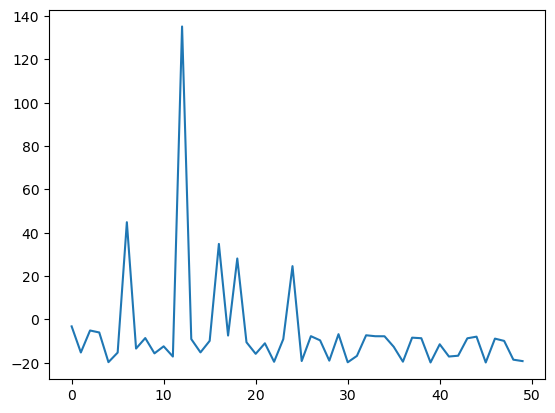

In [26]:
plt.plot(rewards_storage)

In [37]:
# for i in range(100):
#     S_series,O_series,U_series,R_series,O_predicted_series,Done_series,S_actual_series=data_collection(20,dqn_solver,autoencoder)
#     print("epoch: {}, total reward: {}, start state: {}".format(i, sum(R_series), S_series[0]))
#     rewards_storage.append(sum(R_series))
#     clear_output()

19
-18
43
26
20
-27
-7
7
5
28


KeyboardInterrupt: 

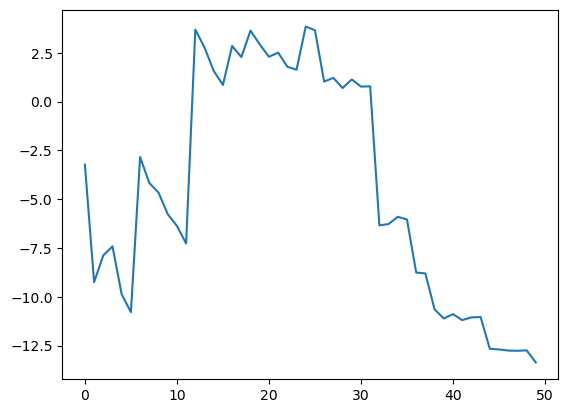

In [28]:
df=pd.DataFrame()
df['rewards']=rewards_storage
plt.plot(df['rewards'].rolling(20,min_periods=1).mean())

In [29]:
df.to_csv('2_12_23_2.nmq.csv')

In [69]:
# for i in range(100):
#     S_series,O_series,U_series,R_series,O_predicted_series,Done_series,S_actual_series=data_collection(20,dqn_solver,autoencoder)
#     print("epoch: {}, total reward: {}, start state: {}".format(i, sum(R_series), S_series[0]))
#     rewards_storage.append(sum(R_series))
#     dqn_training(dqn_solver,1000,S_series,U_series,R_series,Done_series)
#     clear_output()

In [68]:
rewards_storage

[1503.8289118302794,
 1682.012770394984,
 1660.0416539203245,
 1462.3042587220382,
 767.9527181335046,
 924.4218510990295,
 1718.9648492108095,
 1333.7258986286672,
 1491.5902815966438,
 1682.3273835464197,
 1964.2442126168014,
 1536.0954791133217,
 1939.2630739076253,
 1215.323064486418,
 1505.083564353028,
 1650.0137323228807,
 1135.136188675754,
 1426.1449890587257,
 1105.8097189341443,
 1945.077201279924,
 1535.6313266589448,
 1524.5305655121608,
 992.6130750794545,
 739.8224559455426,
 1506.7538784719015,
 1275.677864947799,
 1859.2809782724376,
 1242.7099549230077,
 1510.10759529288,
 1468.3279090443548,
 2181.0873737044967,
 1620.9987364232898,
 1339.1263541184503,
 1834.120207233849,
 895.0207235760123,
 1241.8733238597945,
 1699.387133149617,
 1524.7993010671973,
 1709.054690571586,
 1233.374856619767,
 1074.397950130691,
 1339.8246523219157,
 1277.6521718380684,
 1649.805862543573,
 1558.4385283671495,
 1504.659803621885,
 1808.4867818162995,
 1815.4835457587317,
 1286.869810

In [44]:
S_series,O_series,U_series,R_series,O_predicted_series,Done_series,S_actual_series=data_collection(1,dqn_solver,autoencoder)

-6


In [42]:
O_series

[array([[0]]),
 array([[8]]),
 array([[8]]),
 array([[7]]),
 array([[6]]),
 array([[6]]),
 array([[7]]),
 array([[8]]),
 array([[8]]),
 array([[7]]),
 array([[6]]),
 array([[6]]),
 array([[7]]),
 array([[8]]),
 array([[8]]),
 array([[7]]),
 array([[6]]),
 array([[6]]),
 array([[7]]),
 array([[8]]),
 array([[8]]),
 array([[7]]),
 array([[6]]),
 array([[6]]),
 array([[7]]),
 array([[8]]),
 array([[8]]),
 array([[7]]),
 array([[6]]),
 array([[6]]),
 array([[7]]),
 array([[8]]),
 array([[8]]),
 array([[7]]),
 array([[6]]),
 array([[6]]),
 array([[7]]),
 array([[8]]),
 array([[8]]),
 array([[7]]),
 array([[6]]),
 array([[6]]),
 array([[7]]),
 array([[8]]),
 array([[8]]),
 array([[7]]),
 array([[6]]),
 array([[6]]),
 array([[7]]),
 array([[8]]),
 array([[8]]),
 array([[7]]),
 array([[6]]),
 array([[6]]),
 array([[7]]),
 array([[8]]),
 array([[8]]),
 array([[7]]),
 array([[6]]),
 array([[6]]),
 array([[7]]),
 array([[8]]),
 array([[8]]),
 array([[7]]),
 array([[6]]),
 array([[6]]),
 array([[7

In [43]:
U_series

[array([[0.]], dtype=float32),
 array([[0.]], dtype=float32),
 array([[0.]], dtype=float32),
 array([[0.]], dtype=float32),
 array([[2.]], dtype=float32),
 array([[0.]], dtype=float32),
 array([[0.]], dtype=float32),
 array([[0.]], dtype=float32),
 array([[0.]], dtype=float32),
 array([[0.]], dtype=float32),
 array([[0.]], dtype=float32),
 array([[0.]], dtype=float32),
 array([[0.]], dtype=float32),
 array([[0.]], dtype=float32),
 array([[0.]], dtype=float32),
 array([[0.]], dtype=float32),
 array([[0.]], dtype=float32),
 array([[0.]], dtype=float32),
 array([[0.]], dtype=float32),
 array([[0.]], dtype=float32),
 array([[0.]], dtype=float32),
 array([[0.]], dtype=float32),
 array([[0.]], dtype=float32),
 array([[0.]], dtype=float32),
 array([[0.]], dtype=float32),
 array([[0.]], dtype=float32),
 array([[0.]], dtype=float32),
 array([[0.]], dtype=float32),
 array([[0.]], dtype=float32),
 array([[0.]], dtype=float32),
 array([[0.]], dtype=float32),
 array([[0.]], dtype=float32),
 array([

In [28]:
s=autoencoder.encoder(tf.concat((S_series[17-1],O_series[17],U_series[17-1]),axis=1))
s=np.reshape(s,(1,state_space))
s

array([[-18.119984]], dtype=float32)

In [27]:
O_series[1]

array([[1]])

In [45]:
S_series[12]

array([[11.600154]], dtype=float32)

In [29]:
dqn_solver.model.Qtarget(s)

<tf.Tensor: shape=(1, 1, 5), dtype=float32, numpy=
array([[[ 2.1306171, -4.41109  ,  0.3606875,  3.7895484,  0.932811 ]]],
      dtype=float32)>

In [34]:
dqn_solver.model.Qtarget(np.array([[50]]))

<tf.Tensor: shape=(1, 1, 5), dtype=float32, numpy=
array([[[3.516102 , 6.0505023, 3.737982 , 7.101326 , 2.5570123]]],
      dtype=float32)>

In [39]:
O_series

[array([[0]]),
 array([[-8]]),
 array([[-9]]),
 array([[-8]]),
 array([[-9]]),
 array([[-10]]),
 array([[-11]]),
 array([[-14]]),
 array([[-16]]),
 array([[-18]]),
 array([[-20]]),
 array([[-21]]),
 array([[-21]]),
 array([[-22]]),
 array([[-25]]),
 array([[-25]]),
 array([[-26]]),
 array([[-27]]),
 array([[-26]]),
 array([[-25]]),
 array([[-26]]),
 array([[-28]]),
 array([[-27]]),
 array([[-28]]),
 array([[-28]]),
 array([[-26]]),
 array([[-25]]),
 array([[-24]]),
 array([[-25]]),
 array([[-24]]),
 array([[-23]]),
 array([[-26]]),
 array([[-27]]),
 array([[-24]]),
 array([[-24]]),
 array([[-25]]),
 array([[-27]]),
 array([[-29]]),
 array([[-30]]),
 array([[-33]]),
 array([[-34]]),
 array([[-36]]),
 array([[-38]]),
 array([[-36]]),
 array([[-35]]),
 array([[-36]]),
 array([[-38]]),
 array([[-36]]),
 array([[-36]]),
 array([[-38]]),
 array([[-38]]),
 array([[-37]]),
 array([[-38]]),
 array([[-38]]),
 array([[-37]]),
 array([[-36]]),
 array([[-36]]),
 array([[-34]]),
 array([[-34]]),
 ar

In [78]:
dqn_solver.act(np.array([[89]]))

3

In [48]:
# autoencoder_training(100,autoencoder,S_series,O_series,U_series,tf.keras.optimizers.legacy.Adam(learning_rate=1e-7))

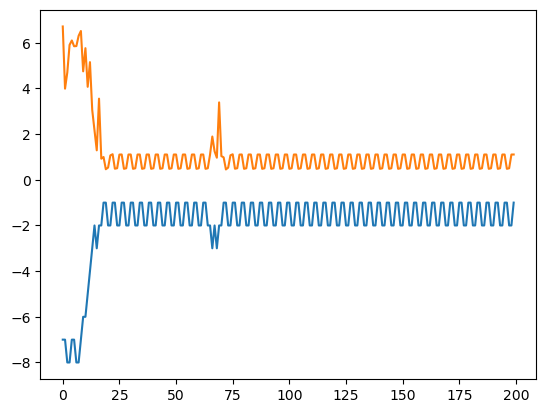

In [45]:
t1=[c[0][0]for c in O_series[1:]]
t2=[c[0][0] for c in O_predicted_series[1:]]
# t3=[c[0][0] for c in S_series[1:]]
plt.plot(t1)
plt.plot(t2)
# plt.plot(t3)
plt.show()

In [54]:
random_rewards=[]

In [55]:
reward_sum=0
for ep in range(1,3021):
    s0=env.reset()
    step=0
    done=False
    j=0
    s=s0
    while (not done) and (j<100):
        j+=1
        action=random.choice([-2,-1,0,1,2])
        s_,reward,done=env.step(s,action)
        reward_sum+=reward
        s=s_
    if (ep%20==0):
        random_rewards.append(reward_sum)
        reward_sum=0


In [51]:
len(random_rewards)

201

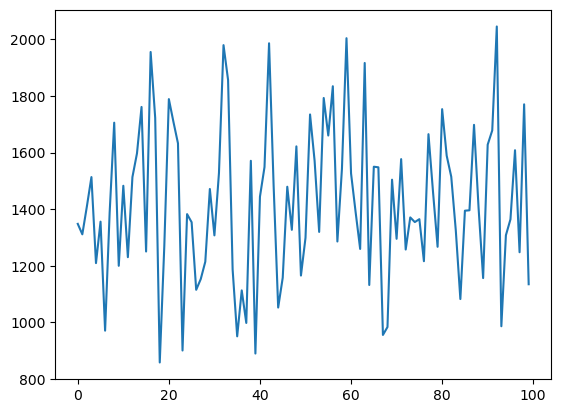

In [52]:
plt.plot(random_rewards[:100])
# plt.plot(rewards_storage)

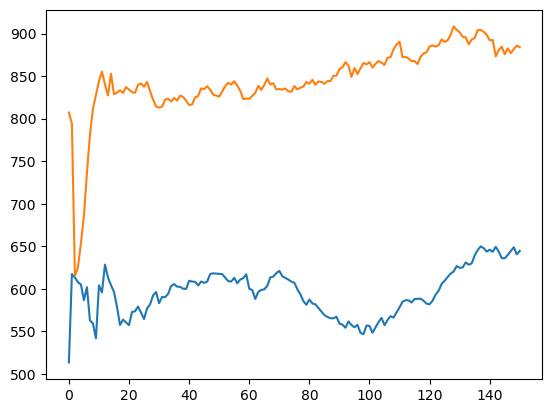

In [56]:
df['random_rewards']=random_rewards
plt.plot(df['random_rewards'].rolling(50,min_periods=1).mean())
plt.plot(df['rewards'].rolling(50,min_periods=1).mean())


In [57]:
df.to_csv('Non_Markovian_20_11.csv')